                                          GAS MONKEY GARAGE

El programa sincroniza los hilos que representan a los autos pasando por el taller de manera que la playa tiene una cierta capacidad (seis autos) y una vez alcanzada no puede hacer el ingreso de otro auto hasta que el auto pasa por los diferentes procesos hasta volver a la playa y se lo retire despues va a comprobar si hay lugar en la zona de fosa para ingresarlo y lo mismo pasa con la zona de fosa la cual tiene capacidad (3 autos) y no va liberar los autos hasta que halla espacio en zona de servicio con dos ayudantes para el cambio de aceite y lavado.

                                  CUELLO DE BOTELLA DETECTADO
Se detecta un cuello de botella el cual se soluciona en el ejercicio el cual se da en la zona de fosa la cual mientras charles repara autos va liberando espacio en la zona de fosa para el ingreso de otro auto en la zona de playa pero como la zona de playa actua como la recepcion de auto como tabien la playa donde el auto va a esperar a ser retirado por el cliente si esta se llena y no es liberada podria haber un estancamiento cuando el auto llegue de forma automatica de la zona de servico a la zona de playa, la solucion fue no liberar la zona de playa hasta que un auto ya alla pasado por todos los procesos se lo deje en la zona de playa y luego se lo retire en ese momento si se podria ingresar un nuevo auto a la zona de playa.

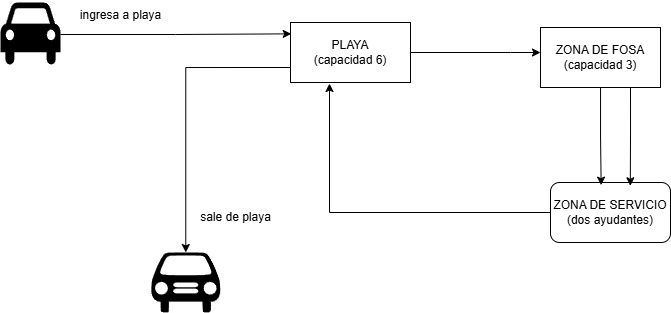

In [ ]:
%%writefile GasMonkeyGarage.cpp
#include <iostream>
#include <thread>
#include <chrono>
#include <vector>
#include <memory>
#include <semaphore>
#include <mutex>

using namespace std;

mutex cout_mutex;

class TallerMecanico 
{
private:
    const int N;

    counting_semaphore<6> espacioPlaya{6};
    counting_semaphore<6> autosParaInspeccion{0};
    counting_semaphore<3> espacioFosa{3};
    counting_semaphore<6> autosParaReparar{0};
    counting_semaphore<2> espacioServicio{2};
    counting_semaphore<1> espacioLavado{1};
    counting_semaphore<1> autoEnReparacion{1};
    counting_semaphore<1> autoEnInspeccion{1};

public:
    TallerMecanico(int n) : N(n) {}

    void richard(int id) 
    {
        espacioPlaya.acquire();
        {
            lock_guard<mutex> lock(cout_mutex);
            cout << "[Auto " << id << "] Richard lo ingresa a la playa." << endl;
        }
        this_thread::sleep_for(chrono::milliseconds(100));
        autosParaInspeccion.release();
    }

    void aaron(int id) 
    {
        autosParaInspeccion.acquire();
        autoEnInspeccion.acquire();
        {
            lock_guard<mutex> lock(cout_mutex);
            cout << "[Auto " << id << "] Aaron lo inspecciona." << endl;
            this_thread::sleep_for(chrono::milliseconds(100));
        }
        autoEnInspeccion.release();
        espacioFosa.acquire();
        autosParaReparar.release();
    }

    void charles(int id) 
    {
        autosParaReparar.acquire();
        autoEnReparacion.acquire();
        {
            lock_guard<mutex> lock(cout_mutex);
            cout << "[Auto " << id << "] ayudante lo traslada a zona de fosa y Charles lo repara." << endl;
        }
        this_thread::sleep_for(chrono::milliseconds(100));
        autoEnReparacion.release();
        espacioServicio.acquire();
        espacioFosa.release();
    }

    void ayudante(int id) 
    {
        {
            lock_guard<mutex> lock(cout_mutex);
            cout << "[Auto " << id << "] Ayudante lo traslada a zona de servicio y cambia el aceite." << endl;
        }
        this_thread::sleep_for(chrono::milliseconds(100));
        espacioServicio.release();

        espacioLavado.acquire();
        {
            lock_guard<mutex> lock(cout_mutex);
            cout << "[Auto " << id << "] Se lava y se lo transporta a playa." << endl;
        }
        this_thread::sleep_for(chrono::milliseconds(100));
        espacioLavado.release();

        espacioPlaya.release();
    }

    void ingresarAuto(int id) 
    {
        richard(id);
        aaron(id);
        charles(id);
        ayudante(id);
    }

    void iniciar() 
    {
        vector<thread> threads;
        for (int i = 0; i < N; ++i) 
        {
            threads.emplace_back(&TallerMecanico::ingresarAuto, this, i + 1);
        }
        for (auto& t : threads) 
        {
            t.join();
        }
        {
            lock_guard<mutex> lock(cout_mutex);
            cout << "Todos los autos fueron atendidos y retirados." << endl;
        }
    }
};

int main(int argc, char* argv[]) 
{
    if (argc != 2) 
    {
        cerr << "Uso: " << argv[0] << " <N_AUTOS>\n";
        return 1;
    }

    int N = stoi(argv[1]);
    TallerMecanico taller(N);
    taller.iniciar();

    return 0;
}

Writing GasMonkeyGarage.cpp


In [ ]:
!ls -la

total 20
drwxr-xr-x 1 root root 4096 May 21 02:26 .
drwxr-xr-x 1 root root 4096 May 21 02:24 ..
drwxr-xr-x 4 root root 4096 May 14 13:38 .config
-rw-r--r-- 1 root root 3180 May 21 02:26 GasMonkeyGarage.cpp
drwxr-xr-x 1 root root 4096 May 14 13:38 sample_data


In [ ]:
!rm GasMonkeyGarage.cpp

In [ ]:
!g++ -std=c++20 -pthread GasMonkeyGarage.cpp -o taller

In [ ]:
!./taller 20

[Auto 1] Richard lo ingresa a la playa.
[Auto 4] Richard lo ingresa a la playa.
[Auto 3] Richard lo ingresa a la playa.
[Auto 5] Richard lo ingresa a la playa.
[Auto 7] Richard lo ingresa a la playa.
[Auto 8] Richard lo ingresa a la playa.
[Auto 1] Aaron lo inspecciona.
[Auto 1] ayudante lo traslada a zona de fosa y Charles lo repara.
[Auto 5] Aaron lo inspecciona.
[Auto 1] Ayudante lo traslada a zona de servicio y cambia el aceite.
[Auto 5] ayudante lo traslada a zona de fosa y Charles lo repara.
[Auto 8] Aaron lo inspecciona.
[Auto 5] Ayudante lo traslada a zona de servicio y cambia el aceite.
[Auto 8] ayudante lo traslada a zona de fosa y Charles lo repara.
[Auto 7] Aaron lo inspecciona.
[Auto 8] Ayudante lo traslada a zona de servicio y cambia el aceite.
[Auto 3] Aaron lo inspecciona.
[Auto 4] Aaron lo inspecciona.
[Auto 7] ayudante lo traslada a zona de fosa y Charles lo repara.
[Auto 1] Se lava y se lo transporta a playa.
[Auto 7] Ayudante lo traslada a zona de servicio y cambia 